# Chain-of-Thought (CoT) with Autonomous RAG

Standard RAG retrieves documents for a high-level query directly, often missing sub-aspects of complex questions. Chain-of-Thought (CoT) RAG first decomposes complex questions into sequential reasoning steps, independently retrieves evidence for each sub-step, and then synthesizes a coherent, multi-step reasoned answer.

## Workflow Architecture

<div align="center">
  <img src="workflow_chain_of_thoughts.png" alt="Chain-of-Thought (CoT) with Autonomous RAG Architecture Diagram" width="580" />
</div>

<details>
<summary><b>Click to expand Colorful Mermaid Source Code</b></summary>

```mermaid
flowchart TD
    subgraph Input["User Complex Inquiry"]
        Q(["1. Complex Question"]):::startNode
    end
    subgraph ReasoningDecomposition["Step 1: Cognitive Planning"]
        Planner["2. planner Node<br/><b>Groq LLM CoT Decomposer</b><br/>(Breaks into 2-3 Reasoning Steps)"]:::planNode
    end
    subgraph MultiStepRetrieval["Step 2: Sub-Query Retrieval"]
        Retriever["3. retriever Node<br/><b>FAISS + MiniLM</b><br/>(Iteratively Fetches Evidence for Sub-Steps)"]:::retrieveNode
    end
    subgraph Synthesis["Step 3: Multi-Step Reasoned Synthesis"]
        Responder["4. responder Node<br/><b>Groq LLM Synthesizer</b><br/>(Integrates Evidence + Reasoning Trail)"]:::llmNode
        Ans(["5. Comprehensive CoT Answer"]):::endNode
    end
    Q --> Planner
    Planner --> Retriever
    Retriever --> Responder
    Responder --> Ans
    classDef startNode fill:#E8F5E9,stroke:#2E7D32,stroke-width:2px,color:#1B5E20;
    classDef planNode fill:#FFF8E1,stroke:#FFA000,stroke-width:2px,color:#E65100;
    classDef retrieveNode fill:#E0F7FA,stroke:#00838F,stroke-width:2px,color:#004D40;
    classDef llmNode fill:#E3F2FD,stroke:#1565C0,stroke-width:2px,color:#0D47A1;
    classDef endNode fill:#FFEBEE,stroke:#D32F2F,stroke-width:2px,color:#B71C1C;
```
</details>

### Key Architectural Highlights
- **Cognitive Query Decomposition**: Deconstructs multifaceted queries into atomic sub-questions.
- **Step-by-Step Retrieval**: Gathers precise local vector context per sub-question, preventing semantic dilution.
- **Holistic Synthesis**: Integrates reasoning trail with retrieved context into an explainable response.


In [47]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import TextLoader

loader = TextLoader("research_notes.txt", encoding="utf-8")
doc = loader.load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(doc)
vectorstore = FAISS.from_documents(
    chunks,
    HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
)
retriever = vectorstore.as_retriever()
print(f"Indexed {len(chunks)} chunks")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5307.81it/s]


Indexed 7 chunks


In [48]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="groq:openai/gpt-oss-120b")
print("LLM ready")

LLM ready


In [49]:
from pydantic import BaseModel
from langchain_core.documents import Document
from typing import List

class RAGCOTState(BaseModel):
    question: str
    sub_steps: List[str] = []
    retrived_doc: List[Document] = []
    answer: str = ""  # default so we can construct with just question=

In [50]:
def plan_sub_steps(state: RAGCOTState) -> RAGCOTState:
    prompt = f"Break the question into 2-3 reasoning steps:\n\n{state.question}"
    result = llm.invoke(prompt).content
    sub_steps = [line.strip("- ") for line in result.split("\n") if line.strip()]
    return state.model_copy(update={"sub_steps": sub_steps})

In [51]:
def retrive_context(state: RAGCOTState) -> RAGCOTState:
    docs = []
    for ques in state.sub_steps:
        docs.extend(retriever.invoke(ques))
    return state.model_copy(update={"retrived_doc": docs})

In [52]:
def generate_answer(state: RAGCOTState) -> RAGCOTState:
    context = "\n\n".join([doc.page_content for doc in state.retrived_doc])
    prompt = f"""You are answering a complex question using reasoning and retrieved documents.

Question: {state.question}

Relevant Information:
{context}

Now synthesize a well-reasoned final answer."""
    result = llm.invoke(prompt)
    return state.model_copy(update={"answer": result.content.strip()})

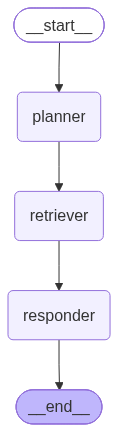

In [53]:
from langgraph.constants import END
from langgraph.graph import StateGraph

builder = StateGraph(RAGCOTState)
builder.add_node("planner",   plan_sub_steps)
builder.add_node("retriever", retrive_context)
builder.add_node("responder", generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner",   "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

# Graph Visualization
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())


In [54]:
query = "what are the additional experiments in Transformer evaluation?"
state = RAGCOTState(question=query)
final = graph.invoke(state)

print("\n🪜 Reasoning Steps:")
for i, step in enumerate(final["sub_steps"], 1):
    print(f"  {i}. {step}")

print("\n✅ Final Answer:\n", final["answer"])


🪜 Reasoning Steps:
  1. **Step 1 – Clarify what “additional experiments” means in the context of Transformer evaluation**
  2. Identify the baseline set of experiments that are usually reported for a new Transformer model (e.g., standard language‑modeling or translation benchmarks, perplexity/accuracy, training curves).
  3. Determine which extra dimensions researchers often explore beyond the core metrics (e.g., robustness, interpretability, efficiency, transferability).
  4. Compile a list of these “additional” categories from recent papers or survey articles on Transformer assessment.
  5. **Step 2 – Gather concrete examples of extra experiments that are commonly added**
  6. For each category from Step 1, pinpoint specific experimental setups that researchers run, such as:
  7. 1. **Robustness & Generalisation** – adversarial attacks, noisy‑input tests, out‑of‑distribution (OOD) evaluation, domain‑shift benchmarks.
  8. 2. **Efficiency & Scalability** – inference latency, FLOPs, m